<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/i.jpeg" alt="scheme" height=70% width=80%>


По сравнению с Contrastive Loss, ArcFace имеет несколько преимуществ.

ArcFace не требует определения порога для различения положительных и отрицательных пар, что упрощает реализацию.

ArcFace явно изучает дискриминационные угловые отношения между классами, что приводит к улучшению межклассовлму разделению.

В Contrastive Loss наблюдается комбинаторный взрыв количества пар лиц, особенно для крупномасштабных наборов данных, что приводит к значительному увеличению количества шагов обучения.

Обучение ArcFace можно проводить без анализа выборки.

ArcFace показал превосходную производительность в крупномасштабных задачах идентификации лиц, где количество идентификаторов огромно.

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/angle_loss.png" alt="scheme" height=60% width=60%>

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/SoftmaxArcface.png" alt="scheme" height=50% width=50%>

### ArcFace Loss

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/Loss.png" alt="scheme" height=70% width=70%>

where **S** is the scaling factor,

**m** is the angular margin (m ~ 28.6),

**theta** is the angle between the feature and the weight vector of the ground truth class, and 

**theta_j** is the angle between the feature and the weight vector of all other classes.

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/arcface.jpg" alt="scheme" height=90% width=90%>

### Reformulate the cross-entropy loss

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/CELoss.png" alt="scheme" height=50% width=50%>

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/III/CE_Arc.png" alt="scheme" height=50% width=50%>

https://arxiv.org/pdf/1801.07698

https://kevinmusgrave.github.io/pytorch-metric-learning/losses/#arcfaceloss

Example
https://colab.research.google.com/github/KevinMusgrave/pytorch-metric-learning/blob/master/examples/notebooks/SubCenterArcFaceMNIST.ipynb

### Задание

1) Скачать датасет https://github.com/phelber/EuroSAT?tab=readme-ov-file

2) Используя ArcFace Loss обучить нейронку кодировать изображения одного класса похожим образом (всего 10 классов ~3000 изображений на класс)

3) С помощью t-SNE визуализировать результаты работы (использовать тестовый датасет)

4) Визуализировать результаты работы (inference) в виде - пара изображений + distance

#### Dataset

https://github.com/phelber/EuroSAT?tab=readme-ov-file

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from PIL import Image

import random

In [6]:
import tifffile
import numpy as np

def tiff_loader(path):
    img = tifffile.imread(path)
    img = img.astype(np.float32) / 10000.0
    # Select RGB bands: EuroSAT MS bands are:
    # 0:B1, 1:B2(B), 2:B3(G), 3:B4(R), 4:B5, 5:B6, 6:B7, 7:B8, 8:B8a, 9:B9, 10:B10, 11:B11, 12:B12
    # So RGB is indices [3, 2, 1]
    rgb = img[:, :, [3, 2, 1]]
    # Clip to [0, 1] just in casemargin
    rgb = np.clip(rgb, 0, 1)
    return rgb

def load_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((128, 128)),
    ])
    
    dataset = ImageFolder(
        root='EuroSAT_MS', 
        transform=transform,
        loader=tiff_loader, 
        is_valid_file=lambda x: x.endswith(".tif")
    )
    
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    
    print(f'Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}')
    
    return train_loader, test_loader

def build_model():
    model = resnet18(pretrained=True)
    model.fc = nn.Linear(512, 128) 
    return model

In [10]:
class CosineLayer(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):

        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)

        cosine = torch.mm(x, w.t())
        
        return cosine

In [11]:
def arcface_loss(cosine, labels, margin=0.5, scale=30):

    cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)

    theta = torch.acos(cosine)

    one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()

    theta_m = theta + one_hot * margin

    cosine_m = torch.cos(theta_m)

    logits = cosine_m * scale

    loss = F.cross_entropy(logits, labels)

    return loss

In [12]:
def train_custom_arcface(model, loader):

    best_loss = float('inf')
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    model.to(device)

    cosine = CosineLayer(128, 10).to(device)

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(cosine.parameters()),
        lr=1e-4
    )

    epochs = 10
    model.train()
    for epoch in range(epochs):

        total_loss = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model(images)

            cosine_output = cosine(features)

            loss = arcface_loss(cosine_output, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "best_model_custom.pth")
            print("Model saved")

In [13]:
def get_embeddings(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    embeddings = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)  
            labels = labels.to(device)  
            emb = model(images)
            embeddings.append(emb)
            labels_list.append(labels)

    embeddings = torch.cat(embeddings)
    labels_list = torch.cat(labels_list)

    print(f'Embeddings shape: {embeddings.shape}, Labels shape: {labels_list.shape}')

    return embeddings.cpu().numpy(), labels_list.cpu().numpy()



In [14]:
def visualize_tsne(embeddings, labels):

    tsne = TSNE(n_components=2)

    X = tsne.fit_transform(embeddings)

    plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10')
    plt.show()

In [16]:
def show_image_pairs(model, dataset, device="cuda", num_pairs=5, threshold=0.5):
    model.eval()
    model.to(device)
    
    dataset_size = len(dataset)
    indices = random.sample(range(dataset_size), min(dataset_size, num_pairs*2)) 
    
    with torch.no_grad():
        for i in range(0, len(indices), 2):
            img1, _ = dataset[indices[i]]
            img2, _ = dataset[indices[i+1]]
            
            img1 = img1.unsqueeze(0).to(device)
            img2 = img2.unsqueeze(0).to(device)
            
            emb1 = model(img1)
            emb2 = model(img2)
            
            cos_sim = F.cosine_similarity(emb1, emb2).item()
            prediction = "Same" if cos_sim > threshold else "Different"
            
            plt.figure(figsize=(4,2))
            
            plt.subplot(1,2,1)
            plt.imshow(img1.squeeze().permute(1,2,0).cpu())
            plt.axis("off")
            
            plt.subplot(1,2,2)
            plt.imshow(img2.squeeze().permute(1,2,0).cpu())
            plt.title(f"{prediction}\nSim: {cos_sim:.2f}")
            plt.axis("off")
            
            plt.tight_layout()
            plt.show()

In [17]:
train_loader, test_loader = load_data()
    
model_custom = build_model()
    
train_custom_arcface(model_custom, train_loader)
model_custom.load_state_dict(torch.load("best_model_custom.pth", map_location="cuda"))
    
embendings, labels = get_embeddings(model_custom, test_loader)


Training samples: 21600, Testing samples: 5400
Device: cuda
Epoch 1/10 | Loss: 2.6827
Model saved
Epoch 2/10 | Loss: 0.5932
Model saved
Epoch 3/10 | Loss: 0.3590
Model saved
Epoch 4/10 | Loss: 0.2405
Model saved
Epoch 5/10 | Loss: 0.2134
Model saved
Epoch 6/10 | Loss: 0.1500
Model saved
Epoch 7/10 | Loss: 0.1648
Epoch 8/10 | Loss: 0.1394
Model saved
Epoch 9/10 | Loss: 0.1134
Model saved
Epoch 10/10 | Loss: 0.0955
Model saved
Embeddings shape: torch.Size([5400, 128]), Labels shape: torch.Size([5400])


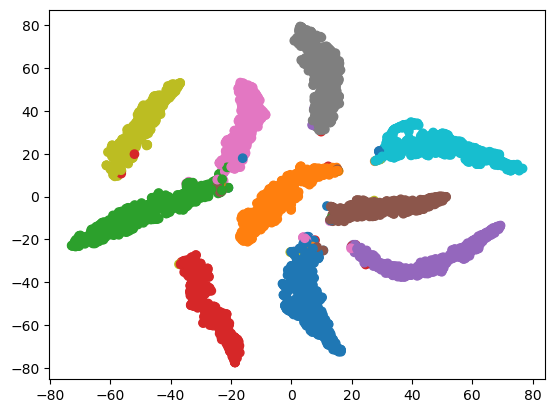

In [18]:
visualize_tsne(embendings, labels)


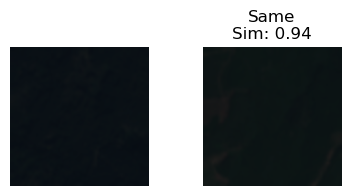

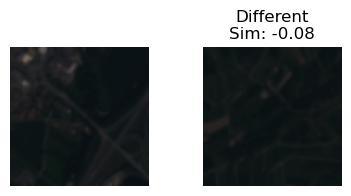

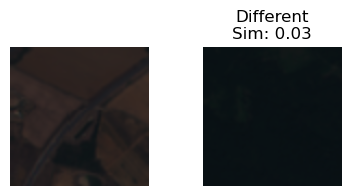

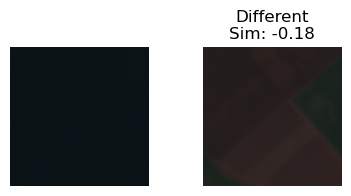

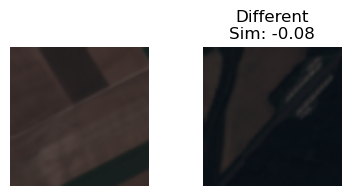

In [19]:
show_image_pairs(model_custom, test_loader.dataset)


In [20]:
import torch
from pytorch_metric_learning import losses

def train_library_arcface(model, loader):
    best_loss = float('inf')
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    model.to(device)

    loss_func = losses.ArcFaceLoss(num_classes=10, embedding_size=128, margin=28.6, scale=64).to(device)

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_func.parameters()),
        lr=1e-4
    )

    epochs = 10
    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Получаем эмбеддинги
            embeddings = model(images)

            # Считаем loss с помощью библиотечной функции
            loss = loss_func(embeddings, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "best_model_library.pth")
            print("Model saved")

In [21]:
# Инициализируем новую модель для библиотечной функции
model_library = build_model()
    
# Обучаем модель с использованием библиотечной реализации
train_library_arcface(model_library, train_loader)
model_library.load_state_dict(torch.load("best_model_library.pth", map_location="cuda"))
    
embendings_lib, labels_lib = get_embeddings(model_library, test_loader)


Device: cuda


/home/cyberpsychoz/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cyberpsychoz/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 | Loss: 5.8631
Model saved
Epoch 2/10 | Loss: 1.3616
Model saved
Epoch 3/10 | Loss: 0.7823
Model saved
Epoch 4/10 | Loss: 0.5121
Model saved
Epoch 5/10 | Loss: 0.4263
Model saved
Epoch 6/10 | Loss: 0.4079
Model saved
Epoch 7/10 | Loss: 0.2686
Model saved
Epoch 8/10 | Loss: 0.2831
Epoch 9/10 | Loss: 0.2963
Epoch 10/10 | Loss: 0.2615
Model saved
Embeddings shape: torch.Size([5400, 128]), Labels shape: torch.Size([5400])


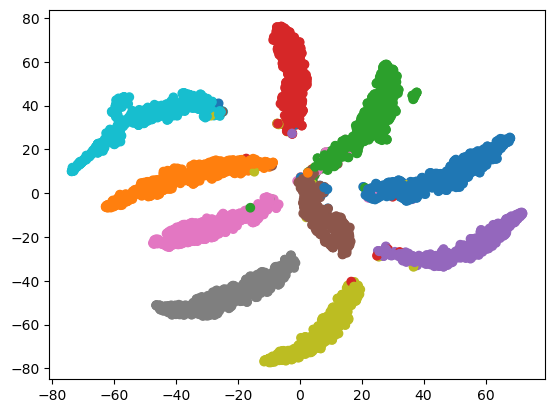

In [22]:
visualize_tsne(embendings_lib, labels_lib)

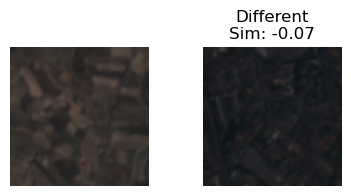

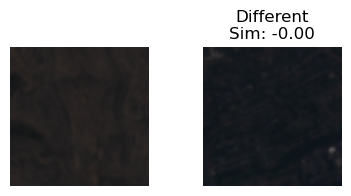

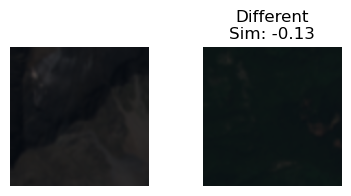

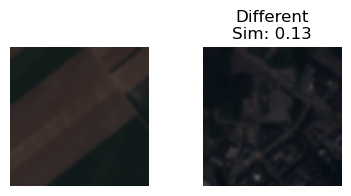

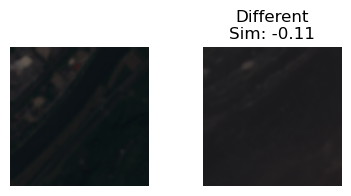

In [23]:
show_image_pairs(model_library, test_loader.dataset)